<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/06_lda_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 6: LDA Topic Modeling

This notebook adds topic-modeling features to the earnings call pipeline. It uses Latent Dirichlet Allocation to identify broad themes in the cleaned prepared remarks and Q&A text, then measures how much each company’s discussion changes from one available quarter to the next.

The topic models are fit only on the training years, then applied to the full dataset. This keeps the 2024 test year from shaping the vocabulary or topic space.

## What this notebook does

- Reads `584_earnings_finbert.parquet` from Step 5.
- Uses the cleaned text columns created in Step 3.
- Fits a shared CountVectorizer vocabulary on training-year text only.
- Fits separate LDA models for prepared remarks and Q&A.
- Creates five topic-probability columns for each section.
- Calculates topic shift using Jensen-Shannon divergence between consecutive available calls for the same ticker.
- Saves the result as `584_earnings_topics.parquet`.

## Output

- `584_earnings_topics.parquet`

New columns added include:

- `prep_topic_1_prob` through `prep_topic_5_prob`
- `qa_topic_1_prob` through `qa_topic_5_prob`
- `prep_dominant_topic`
- `qa_dominant_topic`
- `prep_topic_shift`
- `qa_topic_shift`

## Checks in this notebook

- Prints the top words for each topic.
- Prints topic distributions by transcript.
- Prints Q&A topic-shift scores.
- Ranks quarters by Q&A topic shift.

In [ ]:
# =============================================================================
# STEP 6 — LDA Topic Modeling
# Fit topic models on training-year text, transform all transcripts, and save
# topic probabilities plus quarter-to-quarter topic-shift features.
# =============================================================================

!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/MIS_584_Project"

N_TOPICS     = 5
N_TOP_WORDS  = 10
MAX_FEATURES = 500
RANDOM_STATE = 42

import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

from pyspark.sql import SparkSession

# Start a new Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

spark = SparkSession.builder \
    .master("local") \
    .appName("584_LDA_Topics") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()

sc = spark.sparkContext

# Read the Step 5 checkpoint, which includes the FinBERT scores
PARQUET_IN  = f"{BASE_DIR}/Parquet/584_earnings_finbert"
PARQUET_OUT = f"{BASE_DIR}/Parquet/584_earnings_topics"

df  = spark.read.parquet(PARQUET_IN)
pdf = df.toPandas()
pdf = pdf[pdf['qa_token_count'] > 0].reset_index(drop=True)
pdf = pdf.sort_values(['ticker', 'earnings_date']).reset_index(drop=True)
print(f"Transcripts after dropping empty Q&A: {len(pdf)}")

import pandas as pd
import numpy as np

all_years   = sorted(pdf['year'].unique().tolist())
TEST_YEARS  = [all_years[-1]]
TRAIN_YEARS = all_years[:-1]

train_mask = pdf['year'].isin(TRAIN_YEARS)

print(f"All years in dataset : {all_years}")
print(f"Training years       : {TRAIN_YEARS}")
print(f"Test year            : {TEST_YEARS}")
print(f"Train docs: {train_mask.sum()}  |  Test docs: {(~train_mask).sum()}")

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

prepared_docs = pdf['prepared_remarks_clean'].tolist()
qa_docs       = pdf['qa_section_clean'].tolist()

qa_stop = [
    'think', 'see', 're', 've', 'really', 'like', 'know',
    'say', 'obviously', 'question', 'come', 'go', 'get', 'would'
]

# Fit the vocabulary on training years only
cv = CountVectorizer(max_features=MAX_FEATURES, stop_words=qa_stop)
cv.fit(
    list(pdf.loc[train_mask, 'prepared_remarks_clean']) +
    list(pdf.loc[train_mask, 'qa_section_clean'])
)

dtm_prepared = cv.transform(prepared_docs).toarray()
dtm_qa       = cv.transform(qa_docs).toarray()

print(f"DTM shapes — prepared: {dtm_prepared.shape}  |  qa: {dtm_qa.shape}")


def print_topics(lda_model, feature_names, n_top_words, label):
    print(f"\n{'='*55}\n  {label}\n{'='*55}")
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words = [
            feature_names[i]
            for i in topic.argsort()[-n_top_words:][::-1]
        ]
        print(f"  Topic {topic_idx + 1}: {' | '.join(top_words)}")


feature_names = cv.get_feature_names_out()

# Fit LDA on training years only so the test year does not shape the topics
print("\nFitting LDA on training years only (prepared remarks)...")
lda_prepared = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=RANDOM_STATE,
    max_iter=20, learning_method='online'
)
lda_prepared.fit(dtm_prepared[train_mask])

print("\nFitting LDA on training years only (Q&A sections)...")
lda_qa = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=RANDOM_STATE,
    max_iter=20, learning_method='online'
)
lda_qa.fit(dtm_qa[train_mask])

print_topics(lda_prepared, feature_names, N_TOP_WORDS,
             "PREPARED REMARKS — Top Topics (training years)")
print_topics(lda_qa, feature_names, N_TOP_WORDS,
             "Q&A SECTION — Top Topics (training years)")

# Transform all documents using the train-fitted topic models
theta_prepared = lda_prepared.transform(dtm_prepared)
theta_qa       = lda_qa.transform(dtm_qa)

print("\nTopic distributions per quarter (prepared remarks):")
for i, row in pdf.iterrows():
    dist           = theta_prepared[i]
    dominant_topic = dist.argmax() + 1
    split_label    = 'TRAIN' if row['year'] in TRAIN_YEARS else 'TEST '
    print(f"  [{split_label}] {row['ticker']} {row['quarter']}:  " +
          "  ".join([f"T{j+1}={dist[j]:.3f}" for j in range(N_TOPICS)]) +
          f"  → dominant: Topic {dominant_topic}")

# ── Topic shift via Jensen-Shannon divergence ─────────────────────────────────
from scipy.spatial.distance import jensenshannon


def topic_shift(theta, quarters, tickers):
    """Measure topic shift between consecutive available calls for the same ticker."""
    shifts = []
    for i in range(1, len(theta)):
        if tickers[i] != tickers[i - 1]:
            continue
        js = jensenshannon(theta[i - 1], theta[i])
        shifts.append({
            'from_quarter': quarters[i - 1],
            'to_quarter':   quarters[i],
            'ticker':       tickers[i],
            'topic_shift':  round(float(js), 4),
        })
    return shifts


tickers  = pdf['ticker'].tolist()
quarters = pdf['quarter'].tolist()

shifts_prepared = topic_shift(theta_prepared, quarters, tickers)
shifts_qa       = topic_shift(theta_qa,       quarters, tickers)

print("\n=== Topic Shift Scores — Q&A Section ===")
for s in shifts_qa:
    bar = '█' * int(s['topic_shift'] * 40)
    print(f"  {s['ticker']} {s['from_quarter']} → {s['to_quarter']}:  "
          f"{s['topic_shift']:.4f}  {bar}")

# Add topic columns to pdf
for j in range(N_TOPICS):
    pdf[f'prep_topic_{j+1}_prob'] = theta_prepared[:, j]
    pdf[f'qa_topic_{j+1}_prob']   = theta_qa[:, j]

pdf['prep_dominant_topic'] = theta_prepared.argmax(axis=1) + 1
pdf['qa_dominant_topic']   = theta_qa.argmax(axis=1) + 1

prep_shift_dict = {(s['ticker'], s['to_quarter']): s['topic_shift'] for s in shifts_prepared}
qa_shift_dict   = {(s['ticker'], s['to_quarter']): s['topic_shift'] for s in shifts_qa}

pdf['prep_topic_shift'] = pdf.apply(
    lambda r: prep_shift_dict.get((r['ticker'], r['quarter'])), axis=1
)
pdf['qa_topic_shift'] = pdf.apply(
    lambda r: qa_shift_dict.get((r['ticker'], r['quarter'])), axis=1
)

for col in ['volume_on_date', 'window_days_used']:
    if col in pdf.columns:
        pdf[col] = pdf[col].astype('int64')

df_topics = spark.createDataFrame(pdf)
df_topics.createOrReplaceTempView("earnings_topics")

print("\nAll quarters ranked by Q&A topic shift:")
spark.sql("""
    SELECT ticker, quarter,
        ROUND(prep_topic_shift,       4) AS prep_shift,
        ROUND(qa_topic_shift,         4) AS qa_shift,
        ROUND(prep_net_sentiment,     4) AS net_sentiment,
        ROUND(prep_uncertainty_score, 4) AS uncertainty,
        ROUND(prep_finbert_negative,  4) AS finbert_neg,
        ROUND(pct_return_3d,          4) AS return_3d,
        return_label
    FROM earnings_topics
    ORDER BY qa_shift DESC NULLS LAST
""").show()

df_topics.write.mode('overwrite').parquet(PARQUET_OUT)
print(f"\nSaved to: {PARQUET_OUT}")
print("Verification rows:", spark.read.parquet(PARQUET_OUT).count())

spark.stop()
print("Spark session stopped.")

Streaming output truncated to the last 5000 lines.
  CPRT Q1_FY2024 → Q2_FY2024:  0.2262  █████████
  CPRT Q2_FY2024 → Q4_FY2024:  0.1207  ████
  CPT Q1_FY2021 → Q2_FY2021:  0.0986  ███
  CPT Q2_FY2021 → Q3_FY2021:  0.1844  ███████
  CPT Q3_FY2021 → Q4_FY2021:  0.2324  █████████
  CPT Q4_FY2021 → Q1_FY2022:  0.0598  ██
  CPT Q1_FY2022 → Q2_FY2022:  0.1248  ████
  CPT Q2_FY2022 → Q3_FY2022:  0.0849  ███
  CPT Q3_FY2022 → Q4_FY2022:  0.1309  █████
  CPT Q4_FY2022 → Q1_FY2023:  0.1649  ██████
  CPT Q1_FY2023 → Q3_FY2023:  0.2442  █████████
  CPT Q3_FY2023 → Q4_FY2023:  0.1772  ███████
  CPT Q4_FY2023 → Q1_FY2024:  0.1825  ███████
  CPT Q1_FY2024 → Q2_FY2024:  0.2081  ████████
  CPT Q2_FY2024 → Q4_FY2024:  0.1627  ██████
  CRL Q1_FY2021 → Q2_FY2021:  0.1423  █████
  CRL Q2_FY2021 → Q3_FY2021:  0.1685  ██████
  CRL Q3_FY2021 → Q4_FY2021:  0.2378  █████████
  CRL Q4_FY2021 → Q1_FY2022:  0.1834  ███████
  CRL Q1_FY2022 → Q3_FY2022:  0.2564  ██████████
  CRL Q3_FY2022 → Q4_FY2022:  0.2538  ███

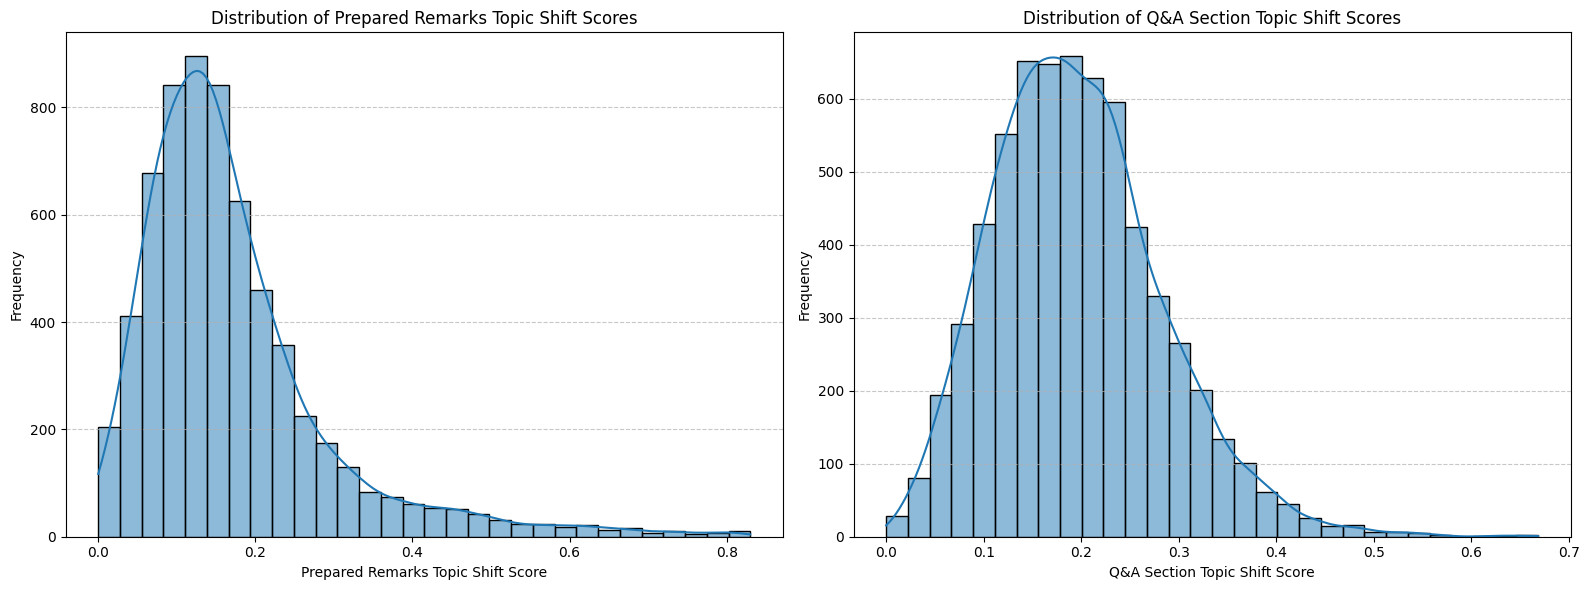

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Prepared Remarks Topic Shift
sns.histplot(pdf['prep_topic_shift'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Prepared Remarks Topic Shift Scores')
axes[0].set_xlabel('Prepared Remarks Topic Shift Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Q&A Section Topic Shift
sns.histplot(pdf['qa_topic_shift'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Q&A Section Topic Shift Scores')
axes[1].set_xlabel('Q&A Section Topic Shift Score')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

In [ ]:
print_topics(lda_prepared, feature_names, N_TOP_WORDS,
             "PREPARED REMARKS — Top Topics")
print_topics(lda_qa, feature_names, N_TOP_WORDS,
             "Q&A SECTION — Top Topics")


  PREPARED REMARKS — Top Topics
  Topic 1: continue | first | earnings | per | expect | share | also | cost | plan | us
  Topic 2: growth | increase | sales | continue | expect | strong | adjust | cost | price | market
  Topic 3: year | growth | over | customers | continue | service | new | grow | non | market
  Topic 4: growth | continue | sales | brand | covid | new | first | increase | drive | include
  Topic 5: increase | growth | net | continue | market | income | year | expense | higher | basis

  Q&A SECTION — Top Topics
  Topic 1: price | kind | yes | next | bite | cost | look | supply | expect | market
  Topic 2: continue | thank | next | growth | us | market | take | first | well | line
  Topic 3: customers | us | one | next | thank | lot | new | talk | time | want
  Topic 4: time | next | kind | look | ll | us | right | yes | well | one
  Topic 5: growth | market | continue | term | us | look | point | give | little | rate


## Exploratory company clustering

This section is an exploratory check using average Q&A topic probabilities by company. It is not used as an input to the final predictive model, but it helps show whether companies group into different discussion profiles.

Clustering performed using 3 clusters based on Q&A topic probabilities.
Companies per cluster:
cluster
1    244
2    159
0    123
Name: count, dtype: int64


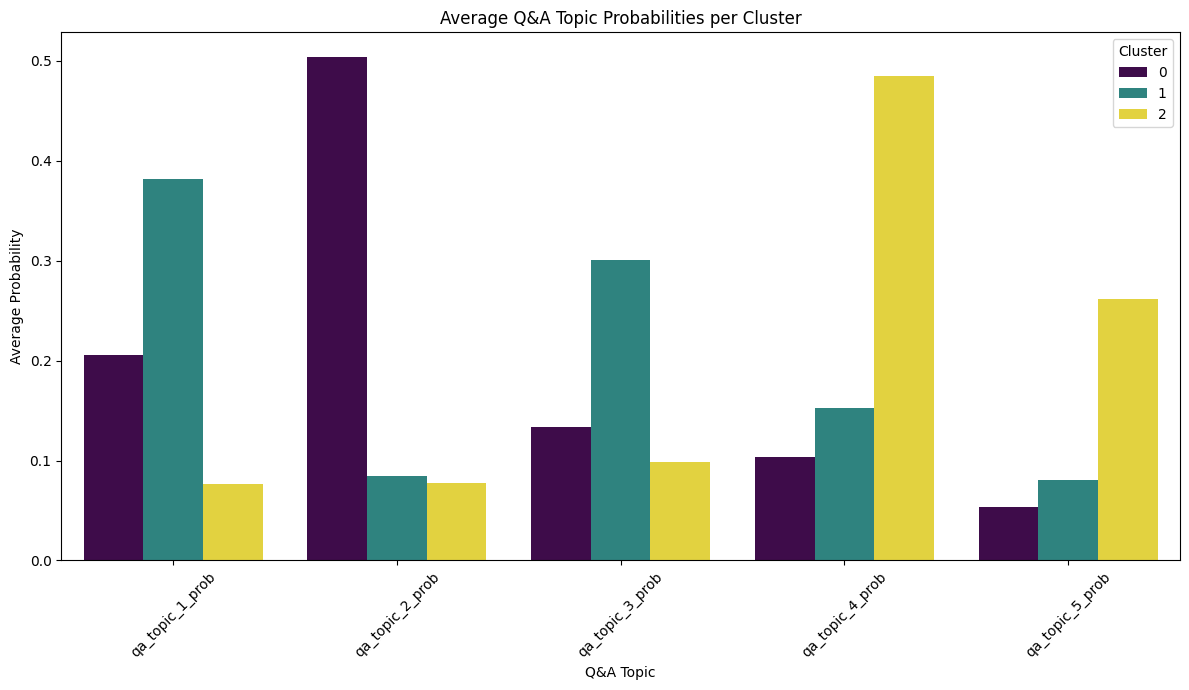


First 10 companies with their assigned clusters:
  ticker  cluster
0      A        1
1    AAL        1
2    AAP        0
3   AAPL        1
4   ABBV        0
5   ABNB        1
6    ABT        0
7   ACGL        2
8    ACN        1
9   ADBE        1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select Q&A topic probability columns
qa_topic_cols = [f'qa_topic_{j+1}_prob' for j in range(N_TOPICS)]

# Aggregate topic probabilities by ticker (average across quarters)
company_topic_profiles = pdf.groupby('ticker')[qa_topic_cols].mean().reset_index()

# Scale the data before clustering
scaler = StandardScaler()
scaled_profiles = scaler.fit_transform(company_topic_profiles[qa_topic_cols])

# Apply K-Means clustering (starting with 3 clusters)
k = 3  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10) # n_init explicitly set
company_topic_profiles['cluster'] = kmeans.fit_predict(scaled_profiles)

print(f"Clustering performed using {k} clusters based on Q&A topic probabilities.")
print("Companies per cluster:")
print(company_topic_profiles['cluster'].value_counts())

# Plot average topic mix for each cluster
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)
cluster_df = pd.DataFrame(cluster_centers, columns=qa_topic_cols)
cluster_df['cluster'] = range(k)

cluster_melted = cluster_df.melt(id_vars=['cluster'], var_name='topic', value_name='average_probability')

plt.figure(figsize=(12, 7))
sns.barplot(data=cluster_melted, x='topic', y='average_probability', hue='cluster', palette='viridis')
plt.title('Average Q&A Topic Probabilities per Cluster')
plt.xlabel('Q&A Topic')
plt.ylabel('Average Probability')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print("\nFirst 10 companies with their assigned clusters:")
print(company_topic_profiles[['ticker', 'cluster']].head(10))


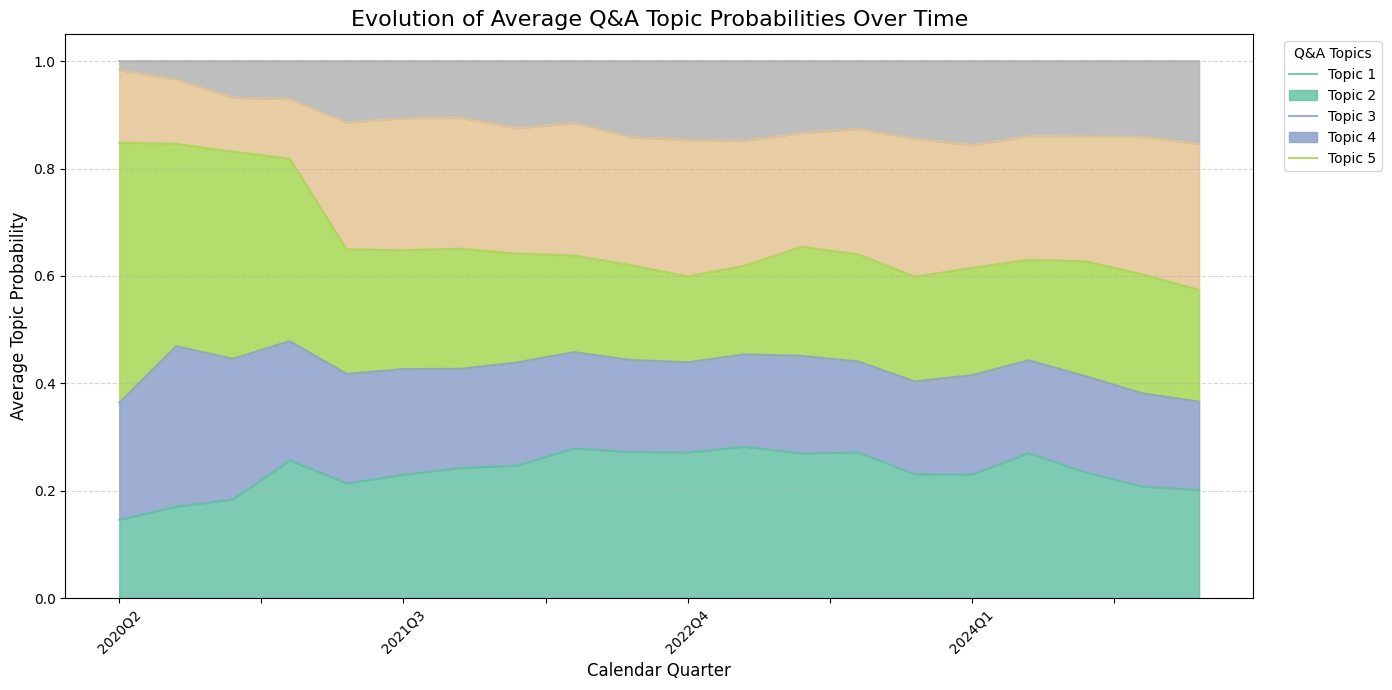

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert earnings_date to datetime to extract chronological periods
pdf['date'] = pd.to_datetime(pdf['earnings_date'])
pdf['period'] = pdf['date'].dt.to_period('Q')

# Group by the chronological quarter and calculate mean topic probabilities
qa_topic_cols = [f'qa_topic_{j+1}_prob' for j in range(N_TOPICS)]
topic_trends = pdf.groupby('period')[qa_topic_cols].mean()

# Convert PeriodIndex to string for cleaner plotting
topic_trends.index = topic_trends.index.astype(str)

# Create a stacked area chart
ax = topic_trends.plot(kind='area', stacked=True, figsize=(14, 7), colormap='Set2', alpha=0.85)

plt.title('Evolution of Average Q&A Topic Probabilities Over Time', fontsize=16)
plt.xlabel('Calendar Quarter', fontsize=12)
plt.ylabel('Average Topic Probability', fontsize=12)

# Formatting legend and layout
plt.legend(
    labels=[f'Topic {i+1}' for i in range(N_TOPICS)],
    title='Q&A Topics',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()